<a href="https://colab.research.google.com/github/SakshyamAryal077/Class-Balancing-Techniques-for-MIT-BIH-ARRYTHMIA-DETECTION./blob/main/smoteenn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If needed, install imbalanced-learn
!pip install imbalanced-learn


In [ ]:
import numpy as np
import torch
from imblearn.combine import SMOTEENN
from google.colab import files
from sklearn.preprocessing import LabelEncoder




In [ ]:
# Load your saved subset files
X_train_small = np.load("X_trainsmall.npy")
y_train_small = np.load("y_trainsmall.npy")

print("Original X_train_small shape:", X_train_small.shape)
print("Original y_train_small shape:", y_train_small.shape)

classes, counts = np.unique(y_train_small, return_counts=True)
print("\nClass distribution before smoteenn:")
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")


Original X_train_small shape: (27010, 360, 1)
Original y_train_small shape: (27010,)

Class distribution before smoteenn:
Class 0: 193
Class 1: 21680
Class 2: 2734
Class 3: 667
Class 4: 1736


In [ ]:
# Convert to 2D because smoteenn works on 2D input: (samples, features)
X_train_flat = X_train_small.reshape(X_train_small.shape[0], -1)

print("Flattened shape for smoteenn:", X_train_flat.shape)


Flattened shape for smoteenn: (27010, 360)


In [ ]:
smote_enn = SMOTEENN(random_state=42)
X_train_smote, y_train_smote = smote_enn.fit_resample(X_train_flat, y_train_small)

print("After SMOTE-ENN X shape:", X_train_smote.shape)
print("After SMOTE-ENN y shape:", y_train_smote.shape)


After SMOTE-ENN X shape: (107699, 360)
After SMOTE-ENN y shape: (107699,)


In [ ]:
# Check new class distribution
classes, counts = np.unique(y_train_smote, return_counts=True)

print("\nClass distribution after smoteenn:")
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")



Class distribution after smoteenn:
Class 0: 21680
Class 1: 21000
Class 2: 21669
Class 3: 21677
Class 4: 21673


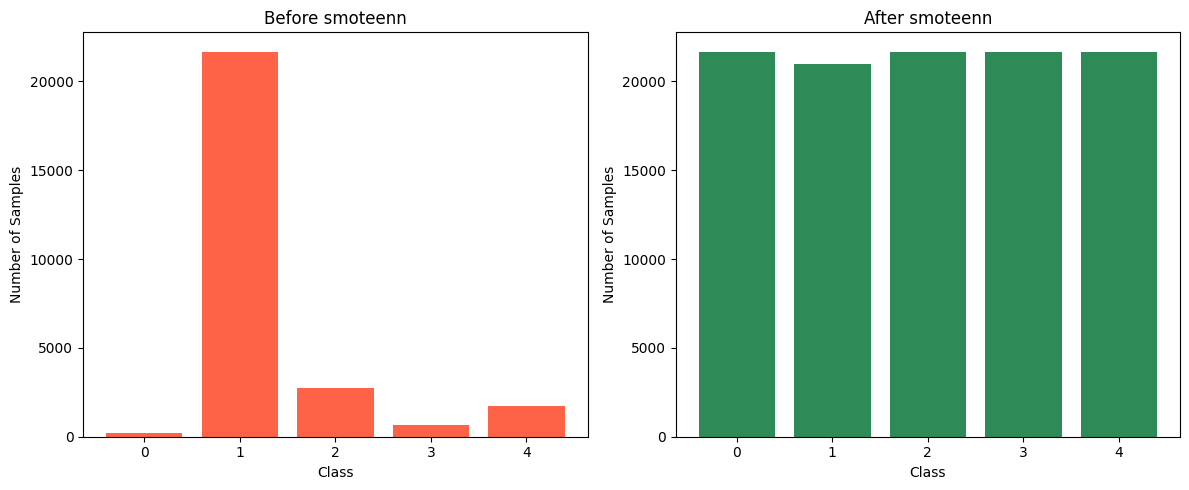

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Before smoteenn
classes_before, counts_before = np.unique(y_train_small, return_counts=True)

# After smoteenn
classes_after, counts_after = np.unique(y_train_smote, return_counts=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(classes_before, counts_before, color='tomato')
plt.title("Before smoteenn")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.subplot(1, 2, 2)
plt.bar(classes_after, counts_after, color='seagreen')
plt.title("After smoteenn")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()


In [ ]:
# Save balanced data
np.save("X_train_smoteenn.npy", X_train_smote)
np.save("y_train_smoteenn.npy", y_train_smote)

print("\nSaved files:")
print("X_train_smoteenn.npy")
print("y_train_smoteenn.npy")



Saved files:
X_train_smoteenn.npy
y_train_smoteenn.npy
